In [7]:
"""
Level 2 - Task 1: Regression Analysis
Codveda Data Analytics Internship

Goal: Predict a stock's closing price based on its opening price using
simple linear regression (illustrated on AAPL, but the function works
for any symbol in the dataset).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os
os.makedirs('outputs', exist_ok=True)

# Update the CSV path to match where the file actually is relative to your notebook
DATA_PATH = '2) Stock Prices Data Set.csv'   # or full Windows path like r'C:\Users\FBDA22-006\...\file.csv'
OUTPUT_DIR = 'outputs'


In [5]:

# ----------------------------------------------------------------------
# 1. Load & prepare data
# ----------------------------------------------------------------------
df = pd.read_csv(r'C:\Users\FBDA22-006\Downloads\stock prices\2) Stock Prices Data Set.csv')
df['date'] = pd.to_datetime(df['date'])

# Drop rows with missing open/high/low (close has no NaNs)
df = df.dropna(subset=['open', 'high', 'low', 'close'])

SYMBOL = 'AAPL'
stock = df[df['symbol'] == SYMBOL].sort_values('date').reset_index(drop=True)
print(f"Rows for {SYMBOL}: {len(stock)}")

# ----------------------------------------------------------------------
# 2. Split into train/test sets
# ----------------------------------------------------------------------
X = stock[['open']]        # predictor: opening price
y = stock['close']         # target: closing price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------------------
# 3. Fit a linear regression model
# ----------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ----------------------------------------------------------------------
# 4. Evaluate the model
# ----------------------------------------------------------------------
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- Linear Regression Results ---")
print(f"Symbol             : {SYMBOL}")
print(f"Intercept           : {model.intercept_:.4f}")
print(f"Coefficient (open)  : {model.coef_[0]:.4f}")
print(f"R-squared           : {r2:.6f}")
print(f"Mean Squared Error  : {mse:.6f}")
print(f"Root MSE            : {rmse:.6f}")

interpretation = (
    f"For every $1 increase in the opening price, the closing price is "
    f"predicted to change by ${model.coef_[0]:.4f}. The model explains "
    f"{r2*100:.2f}% of the variance in closing price (R-squared = {r2:.4f})."
)
print("\nInterpretation:")
print(interpretation)



Rows for AAPL: 1007

--- Linear Regression Results ---
Symbol             : AAPL
Intercept           : 0.2057
Coefficient (open)  : 0.9985
R-squared           : 0.996801
Mean Squared Error  : 1.842077
Root MSE            : 1.357232

Interpretation:
For every $1 increase in the opening price, the closing price is predicted to change by $0.9985. The model explains 99.68% of the variance in closing price (R-squared = 0.9968).


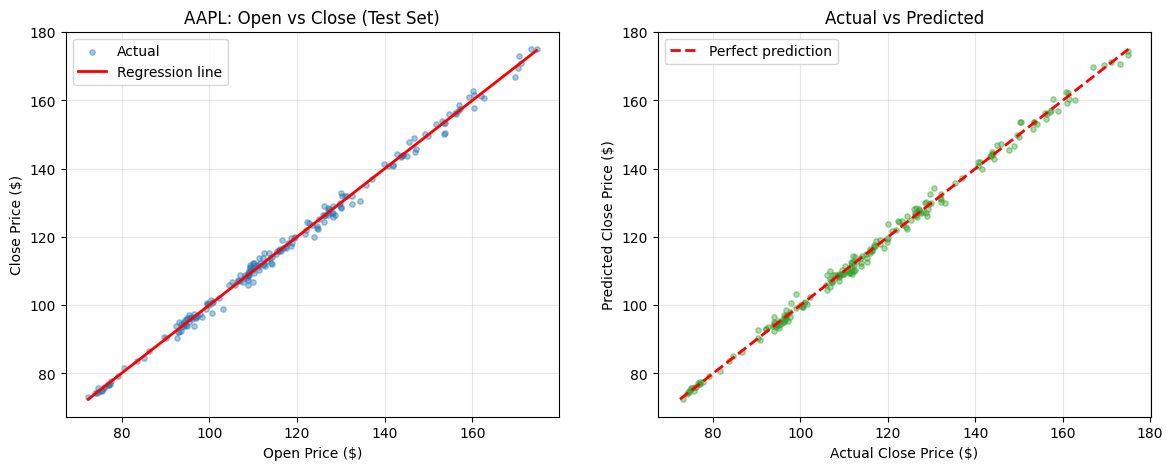

In [9]:

# ----------------------------------------------------------------------
# 5. Plot: Actual vs Predicted
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_test, y_test, alpha=0.4, s=15, label='Actual', color='#1f77b4')
sort_idx = np.argsort(X_test['open'].values)
axes[0].plot(X_test['open'].values[sort_idx], y_pred[sort_idx],
             color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('Open Price ($)')
axes[0].set_ylabel('Close Price ($)')
axes[0].set_title(f'{SYMBOL}: Open vs Close (Test Set)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.4, s=15, color='#2ca02c')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Close Price ($)')
axes[1].set_ylabel('Predicted Close Price ($)')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()
axes[1].grid(alpha=0.3)

